## Loading and Plotting the Raw Spectra

The following function reads any Ba11/ISO `.dat` spectrum file and converts
the recorded *time axis* into a correct *wavelength axis*, using the metadata
(start wavelength, gear factor, scan direction).

It also:
- converts commas to dots (LabVIEW formatting),
- flips the wavelength axis when needed so that λ always increases left → right,
- flips the intensity sign so peaks always point upward,
- automatically chooses the correct wavelength limits for 50 mV and 5 mV scans,
- applies uniform xticks (20 nm spacing for 50 mV, 5 nm spacing for 5 mV).

This function is the foundation for all later analysis steps.


In [64]:
import numpy as np
import matplotlib.pyplot as plt

def plot_spectrum(filename):
    """
    Load and plot any Ba11 (ISO) spectrum file with correct wavelength axis.

    Parameters
    ----------
    filename : str
        Path to the .dat file containing the spectrum.
    """

    # --- Load file and convert commas to dots ---
    with open(filename, "r", encoding="utf-8") as f:
        header1 = f.readline().strip().replace(",", ".")  # start wavelength [nm]
        header2 = f.readline().strip().replace(",", ".")  # gear factor [nm/s]
        header3 = f.readline().strip().replace(",", ".")  # scan direction

        data = np.loadtxt(
            (line.replace(",", ".") for line in f),
            ndmin=2
        )

    # --- Parse metadata ---
    start_wavelength = float(header1)
    gear = float(header2)        # nm per second
    direction = float(header3)   # +1 or -1

    # --- Extract data ---
    t = data[:, 0]               # time [s]
    intensity_raw = data[:, 1]   # voltage [V]
    intensity = -intensity_raw   # flip sign → absorption peaks upward

    # --- Correct wavelength formula ---
    wavelength = start_wavelength + direction * gear * t

    # Flip if necessary
    if wavelength[0] > wavelength[-1]:
        wavelength = wavelength[::-1]
        intensity = intensity[::-1]

    # --- Determine x-axis behavior based on filename ---
    fname = filename.lower()

    if "5mv" in fname:
        x_min, x_max = 670, 720
        xtick_step = 5
    elif "50mv" in fname:
        x_min, x_max = 350, 720
        xtick_step = 20
    else:
        x_min = wavelength.min()
        x_max = wavelength.max()
        xtick_step = 20

    # --- Plot ---
    plt.figure(figsize=(13, 6), dpi=250)
    plt.plot(wavelength, intensity, color="black", linewidth=0.8)

    plt.title(f"Spectrum: {filename}")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Intensity (V)")
    plt.grid(alpha=0.4, linestyle="--")

    plt.xlim(x_min, x_max)

    xticks = np.arange(
        np.floor(x_min / xtick_step) * xtick_step,
        np.ceil(x_max / xtick_step) * xtick_step + xtick_step,
        xtick_step
    )
    plt.xticks(xticks)

    plt.show()
    plt.close()


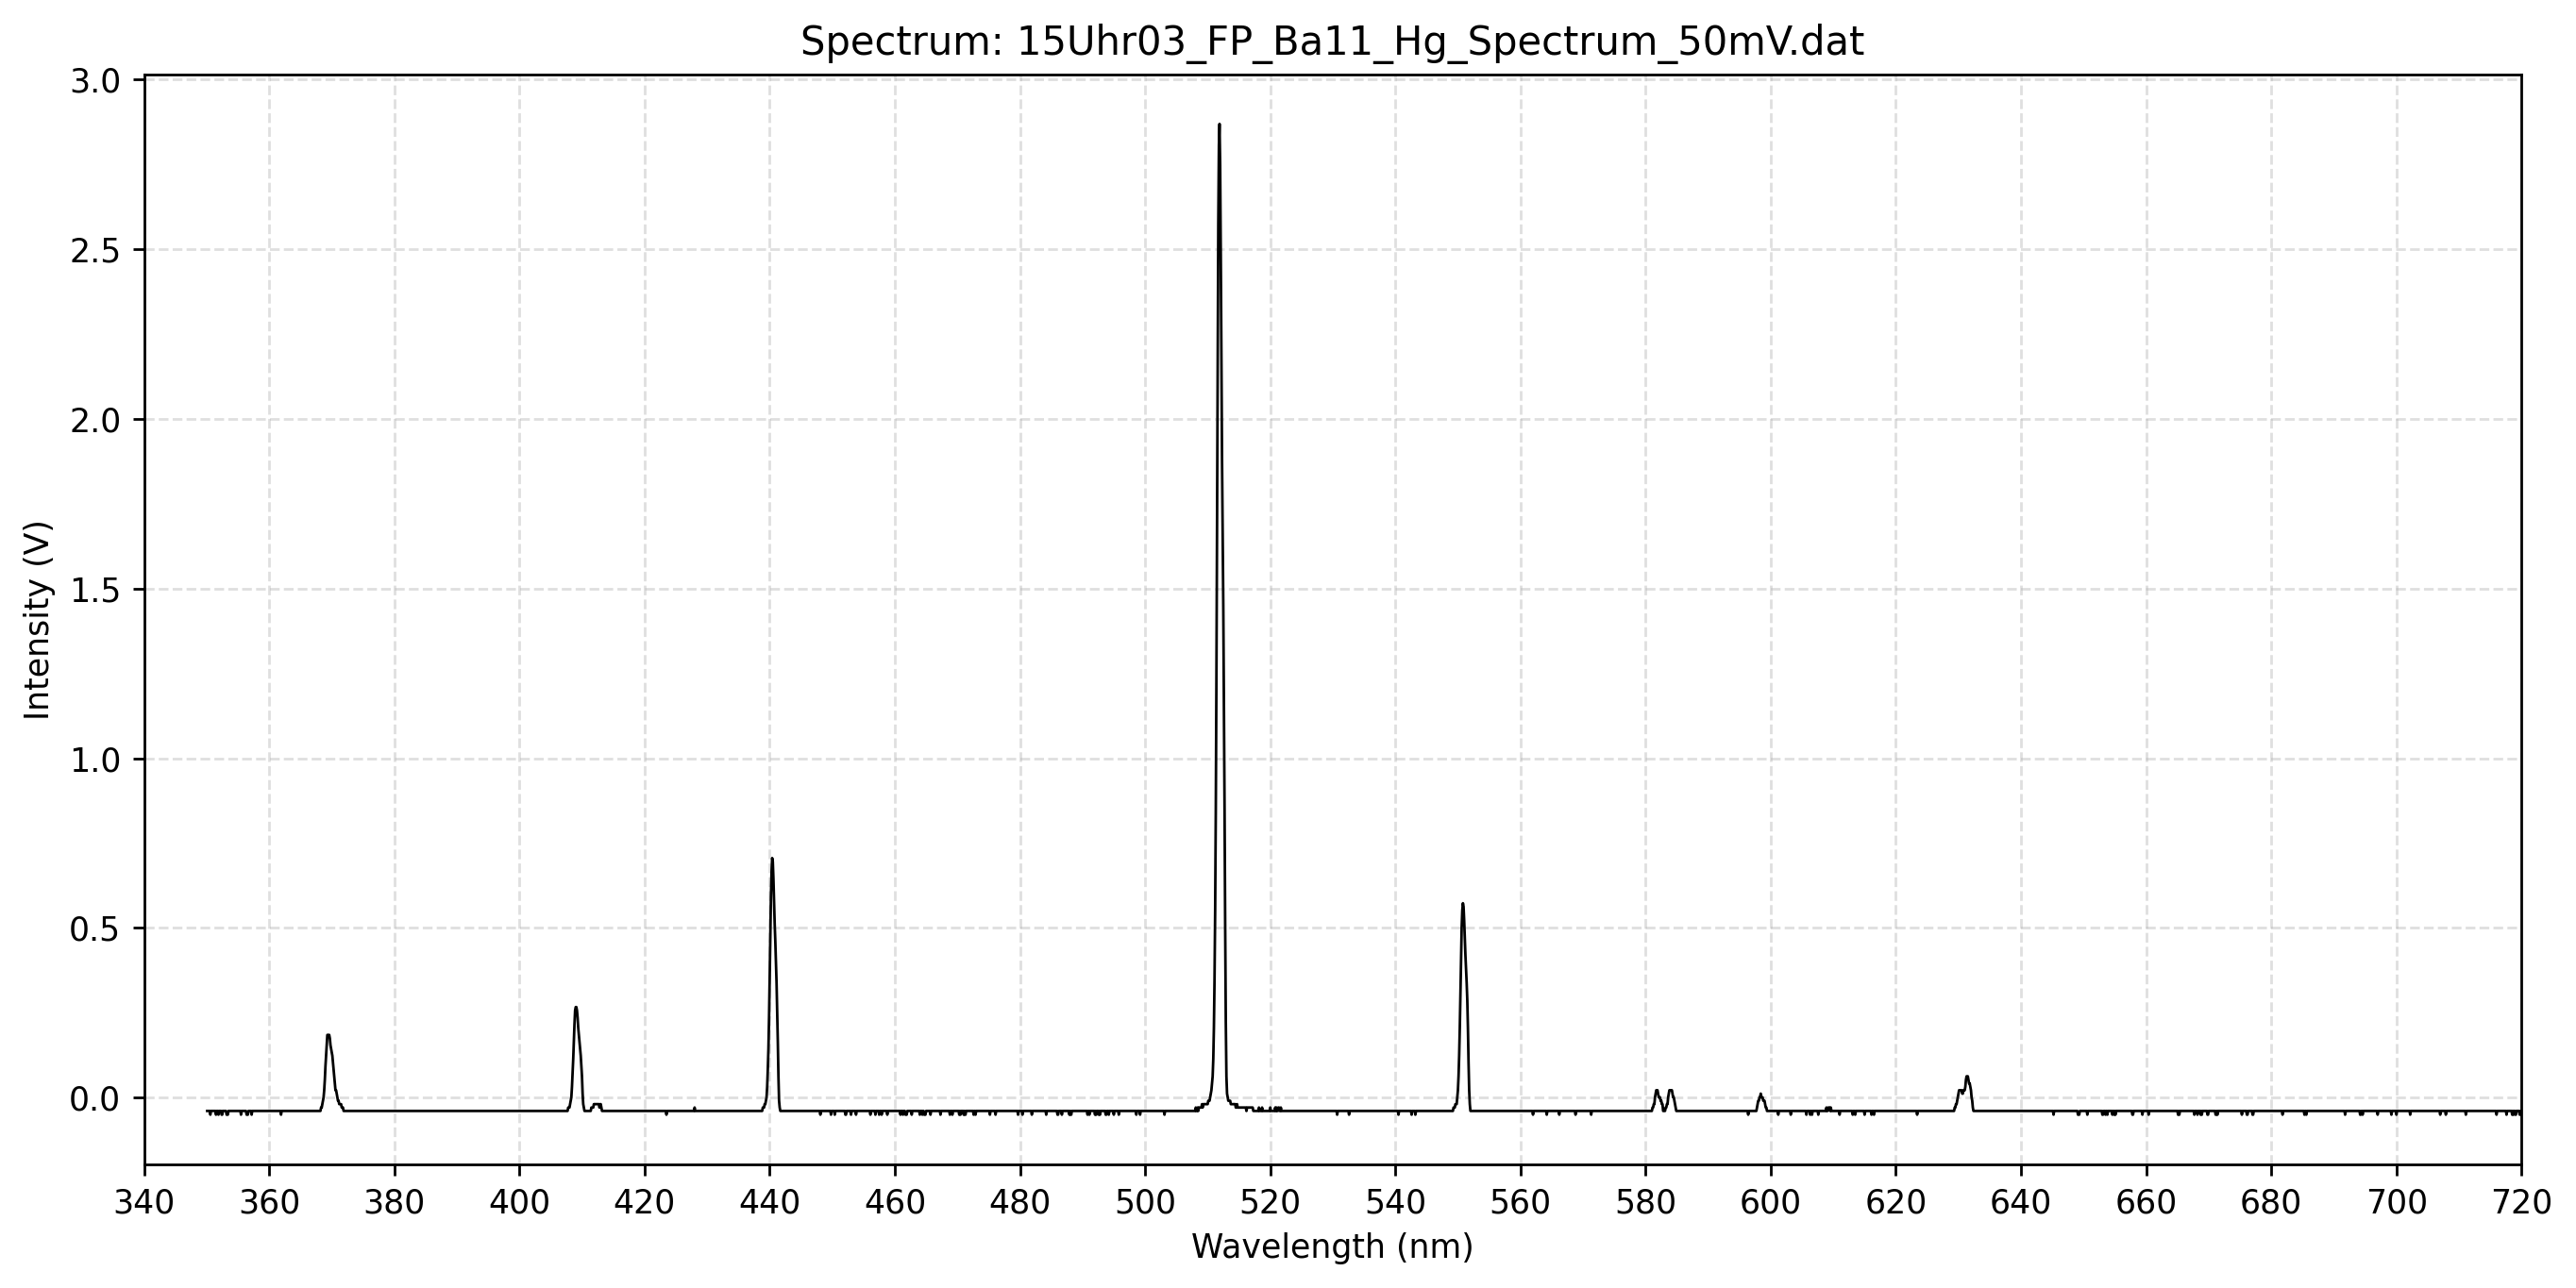

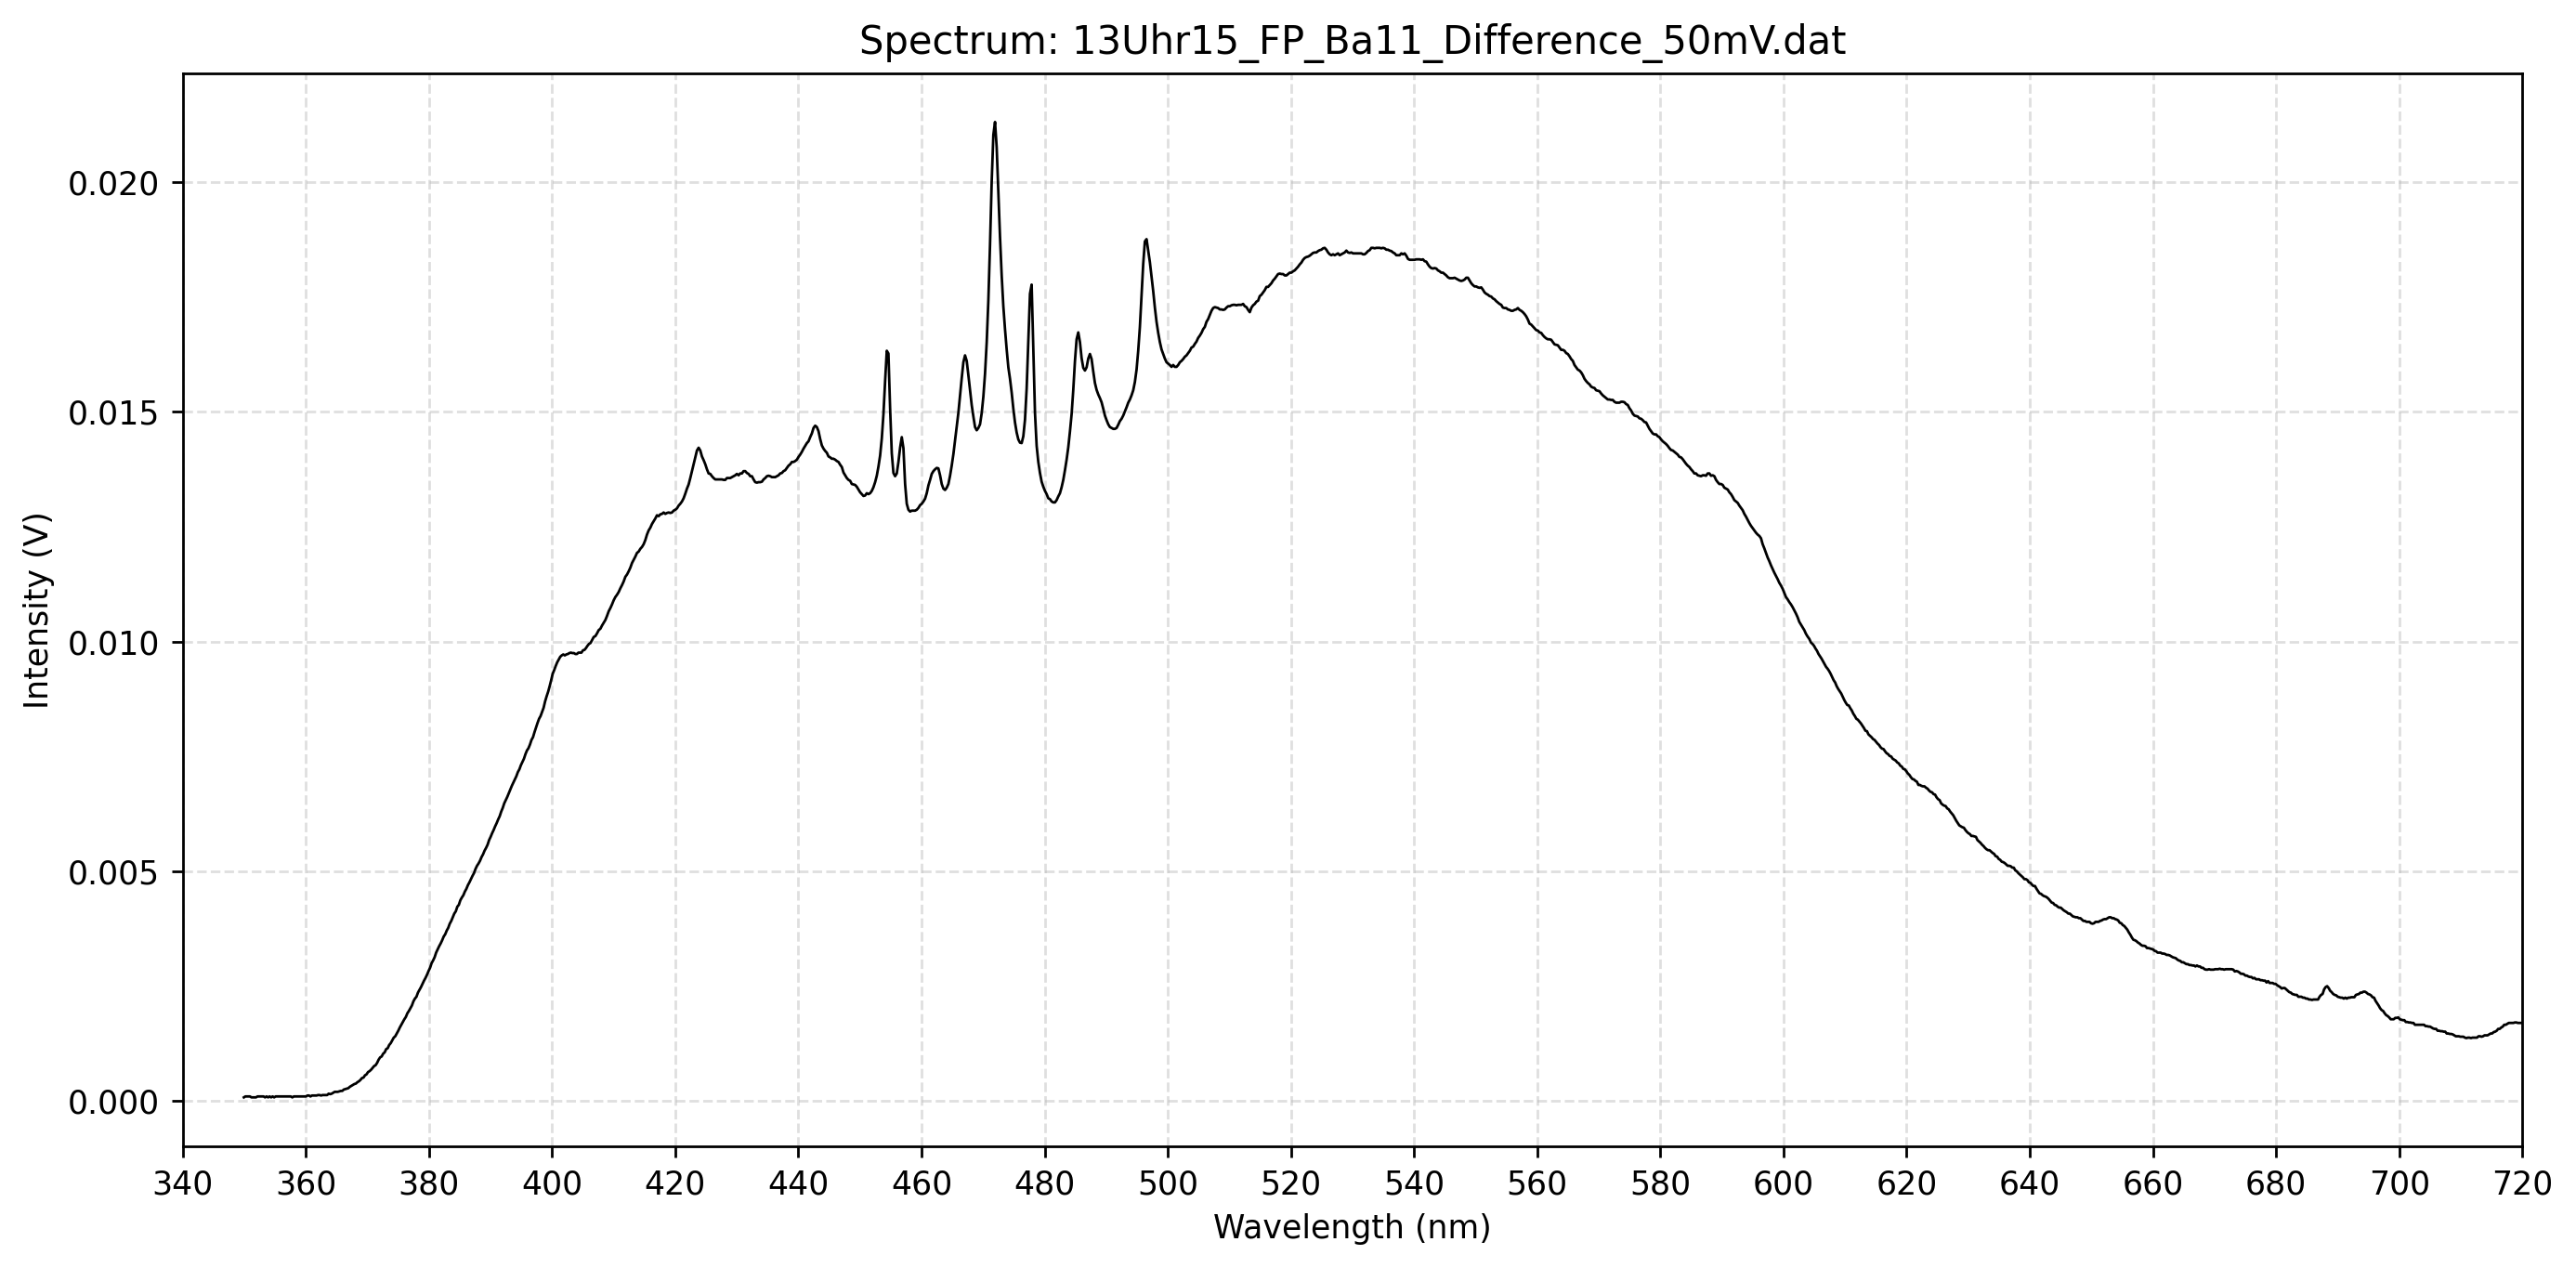

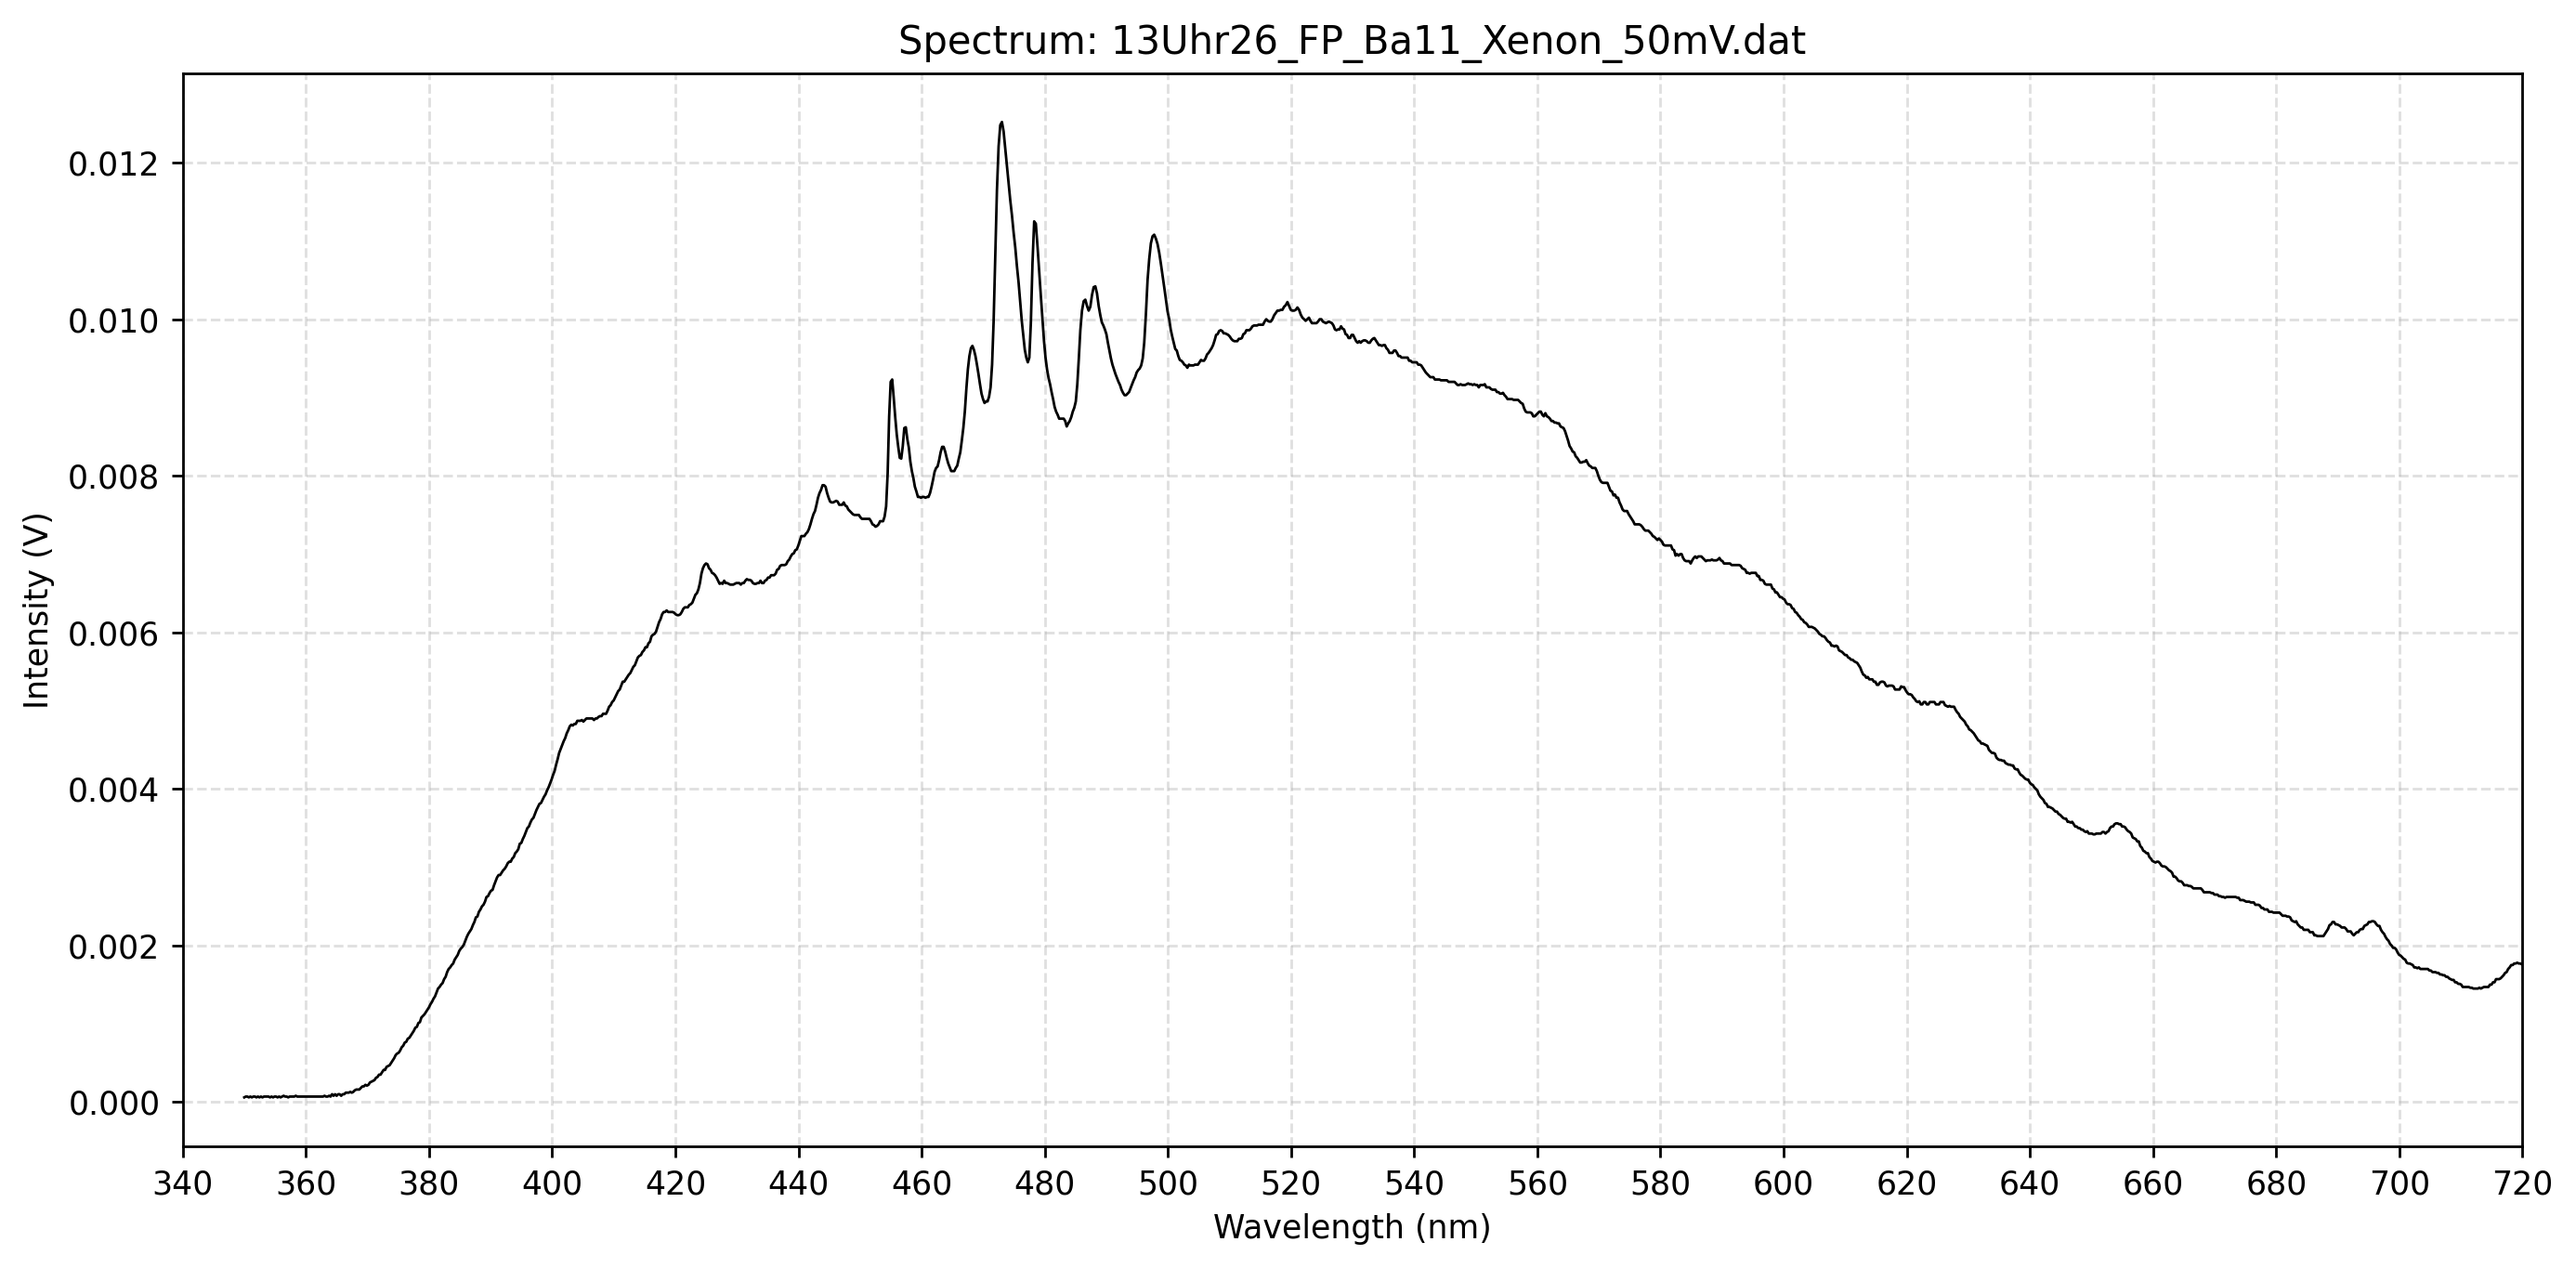

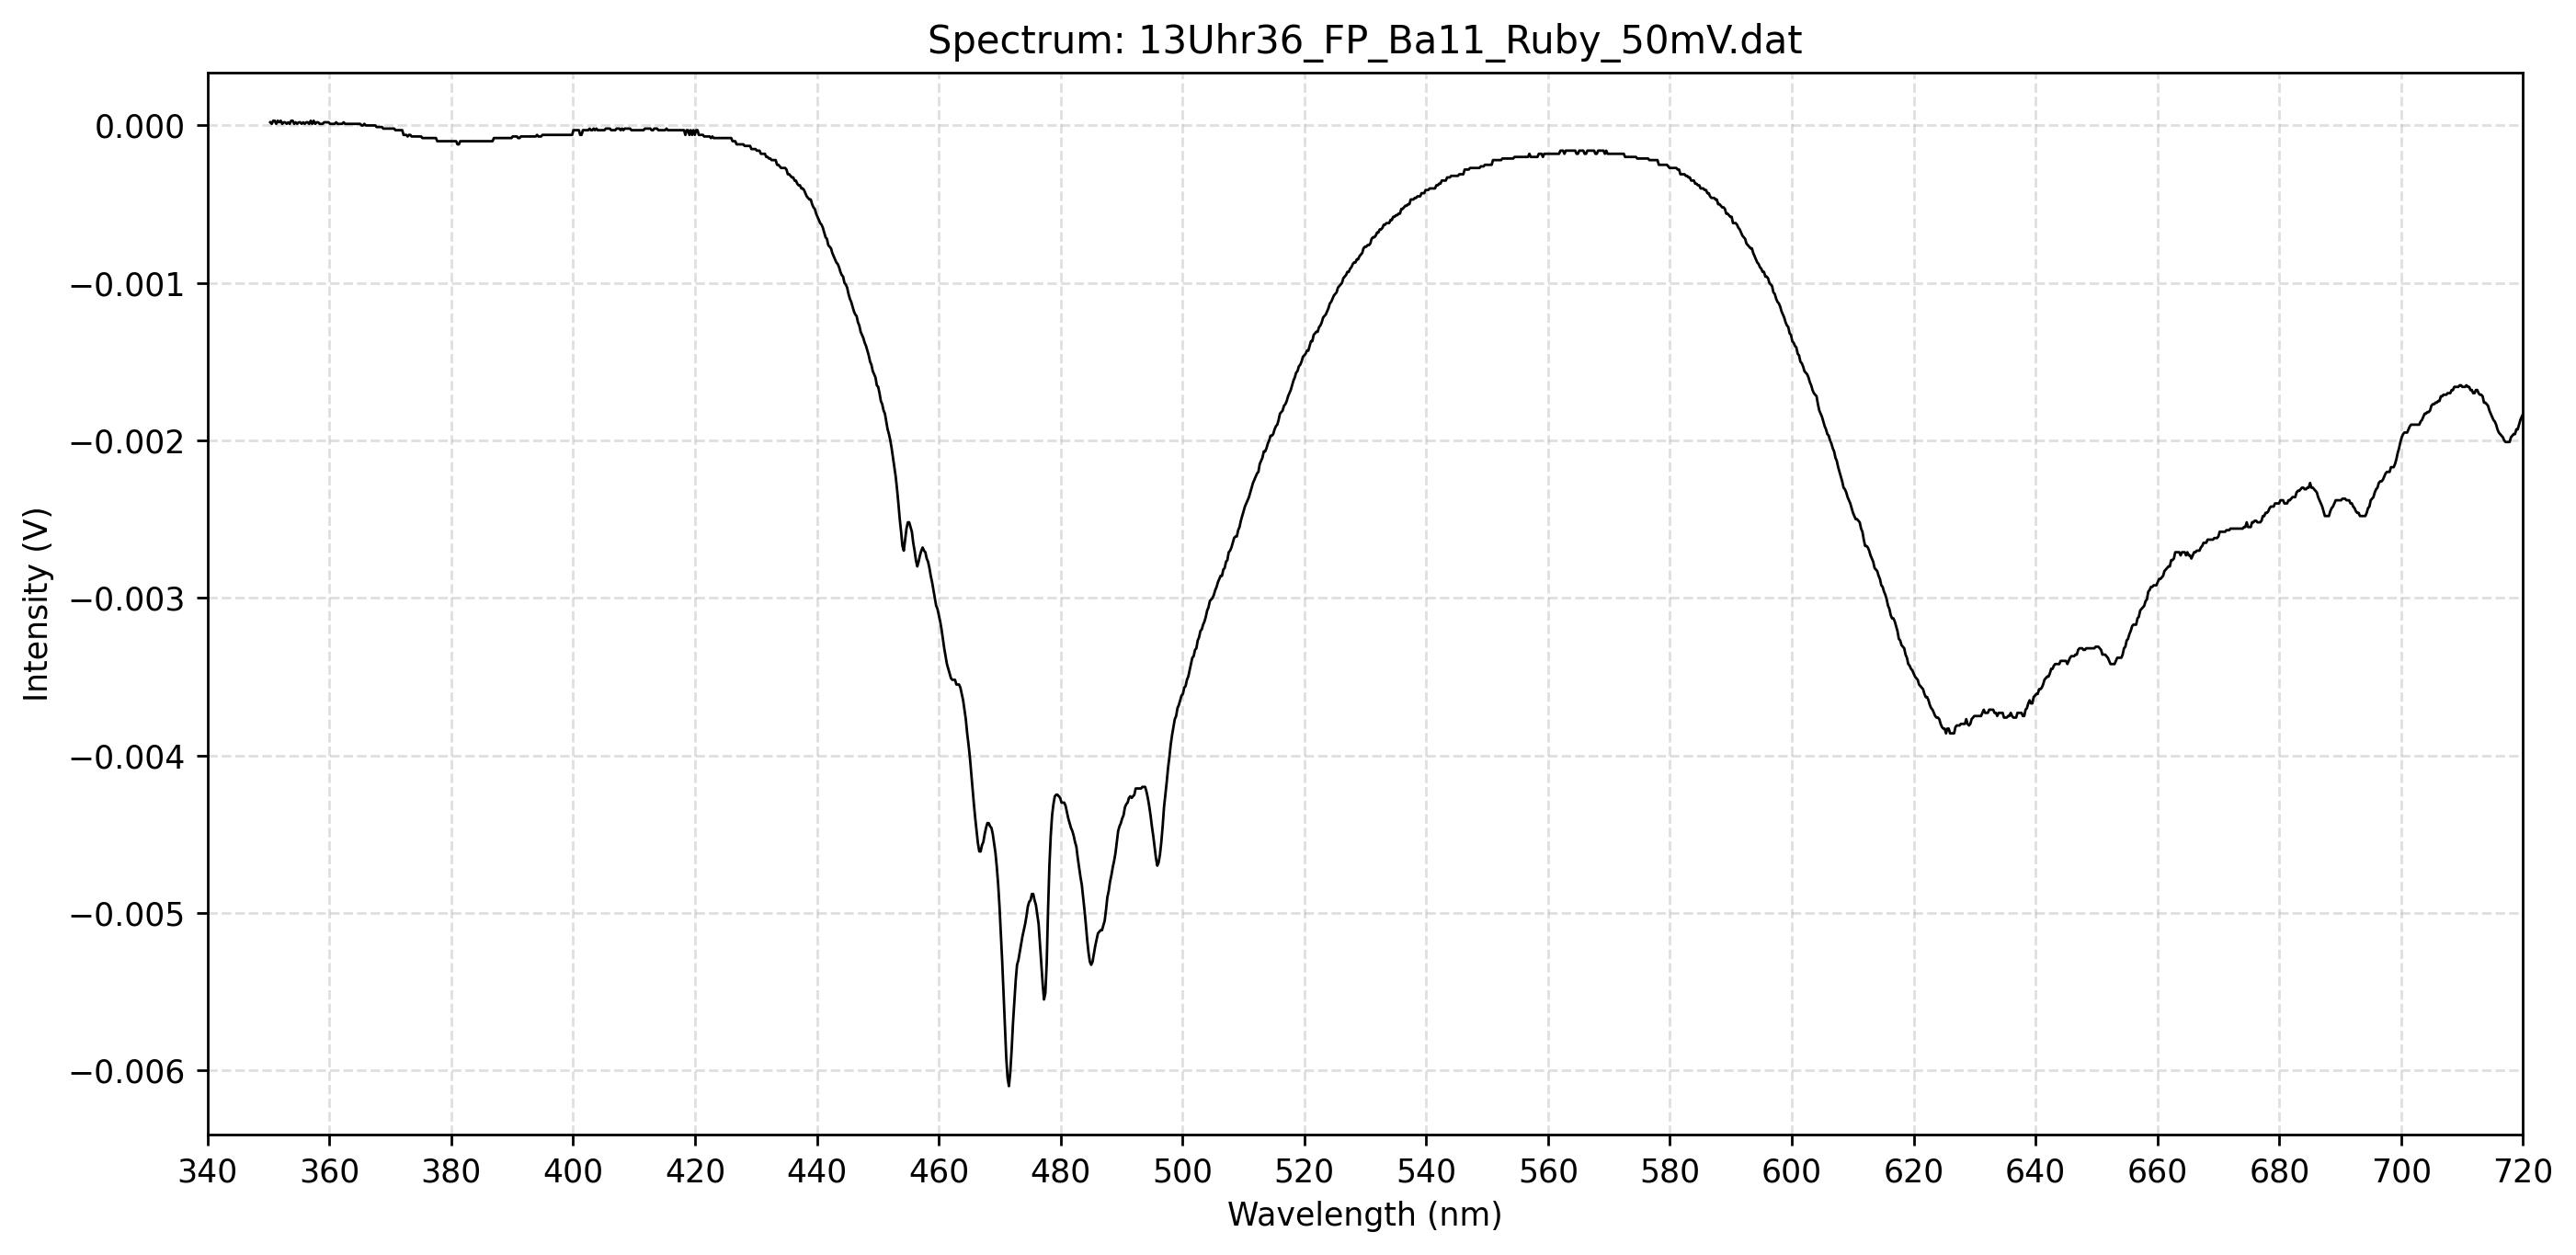

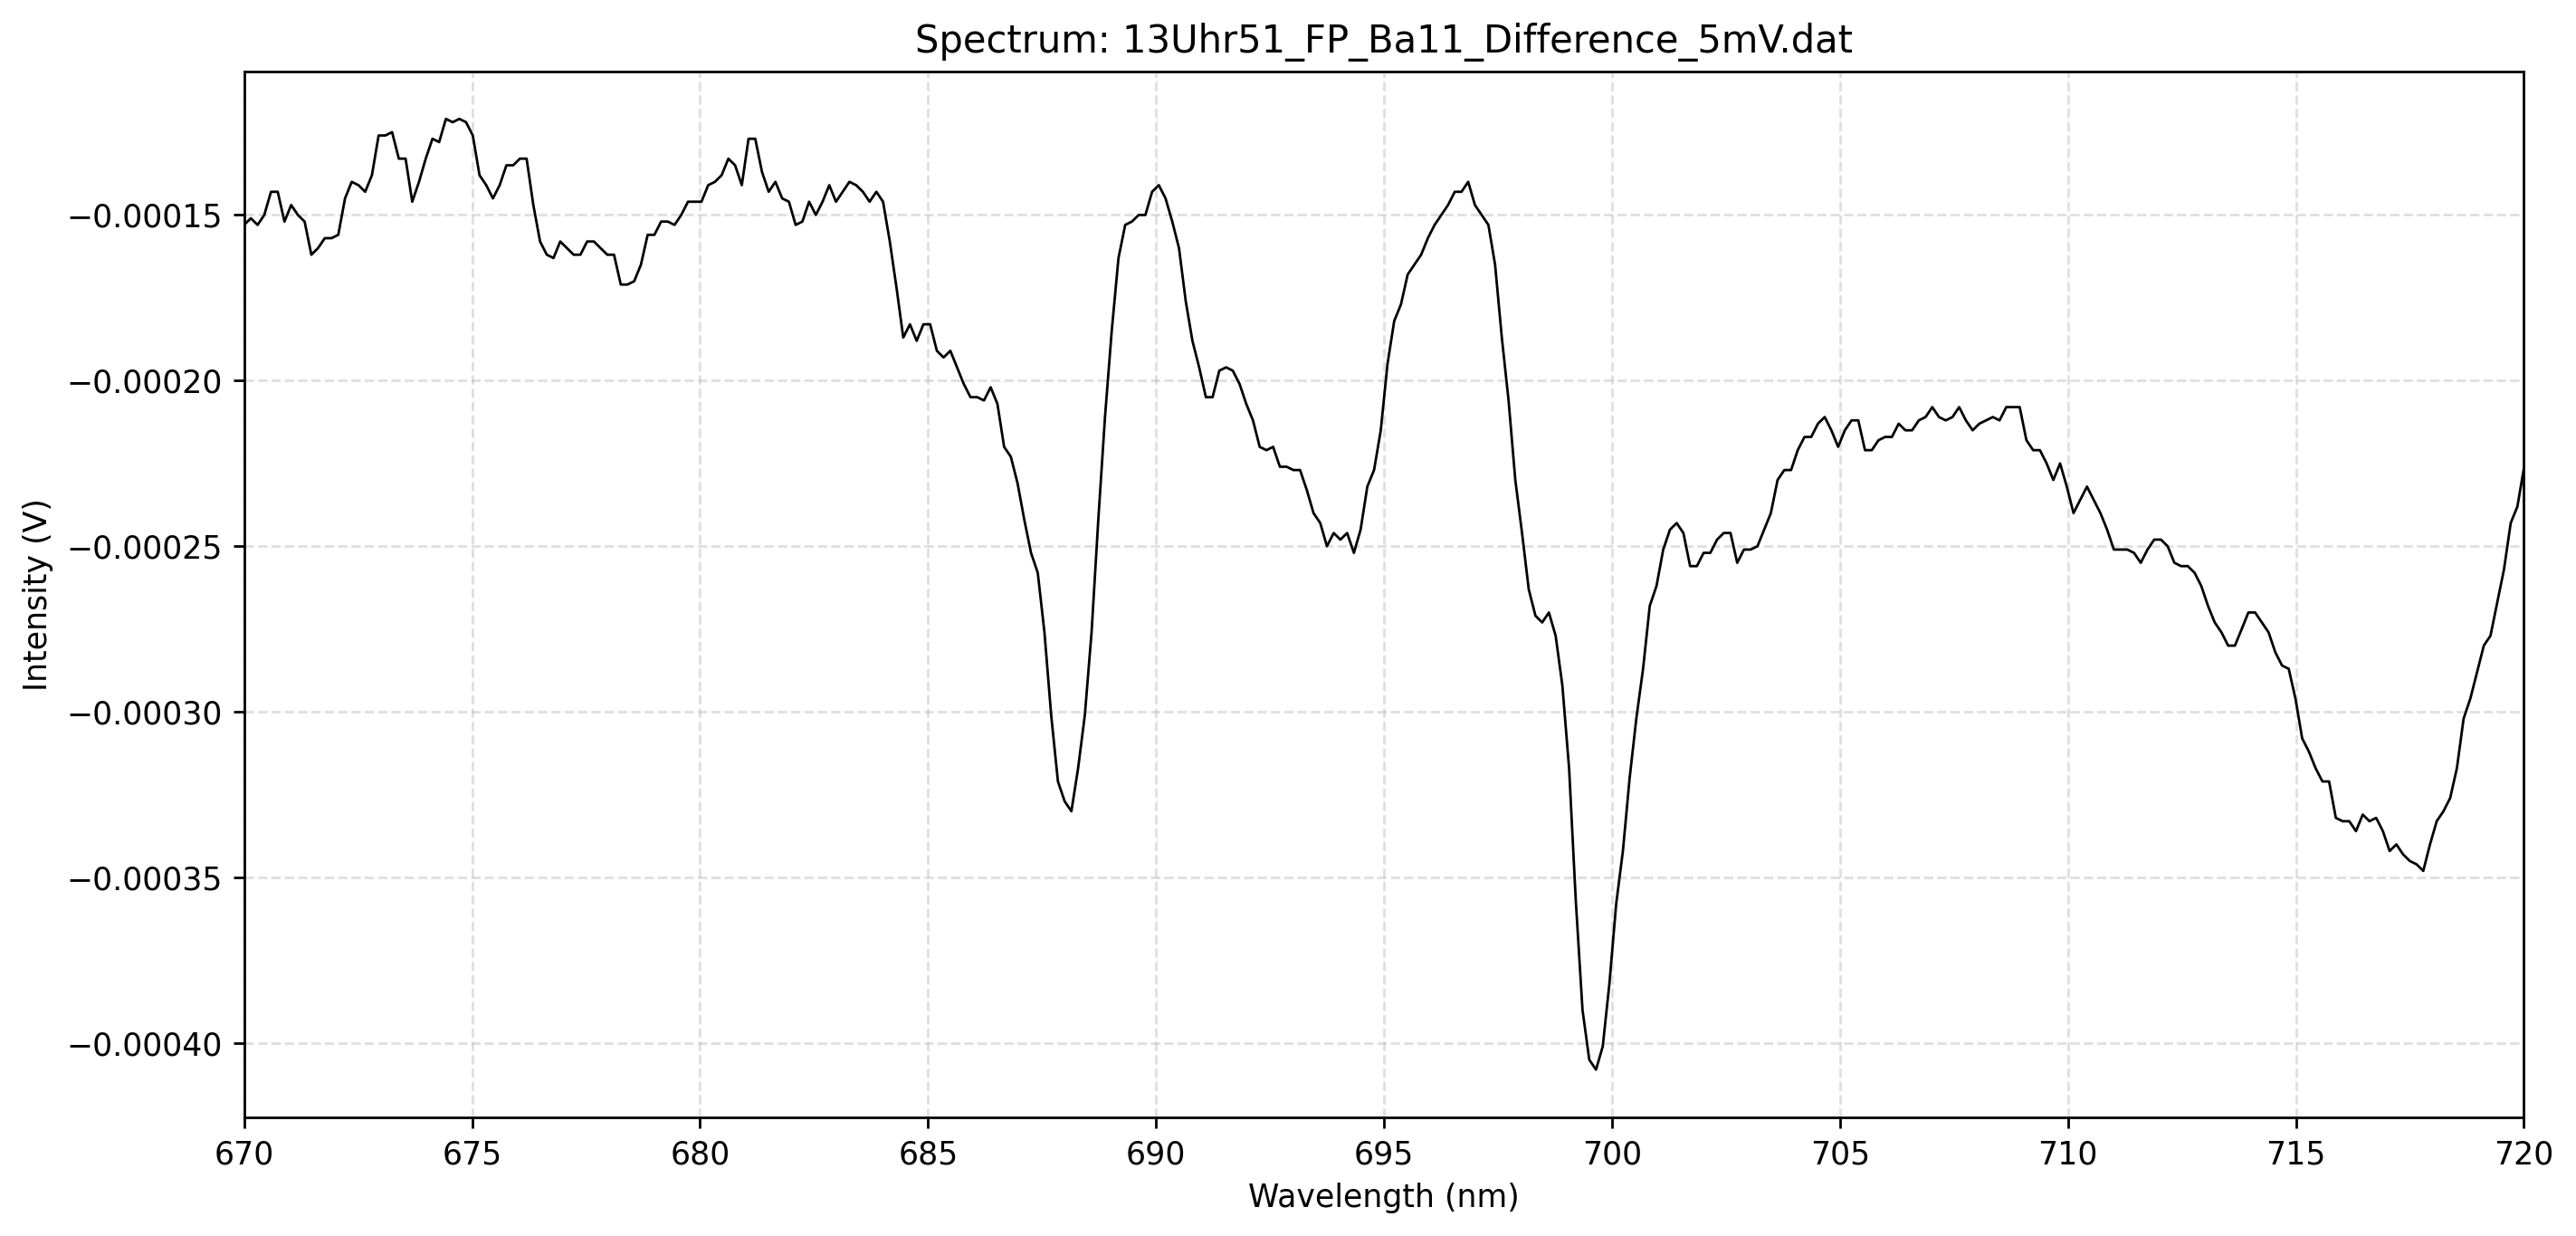

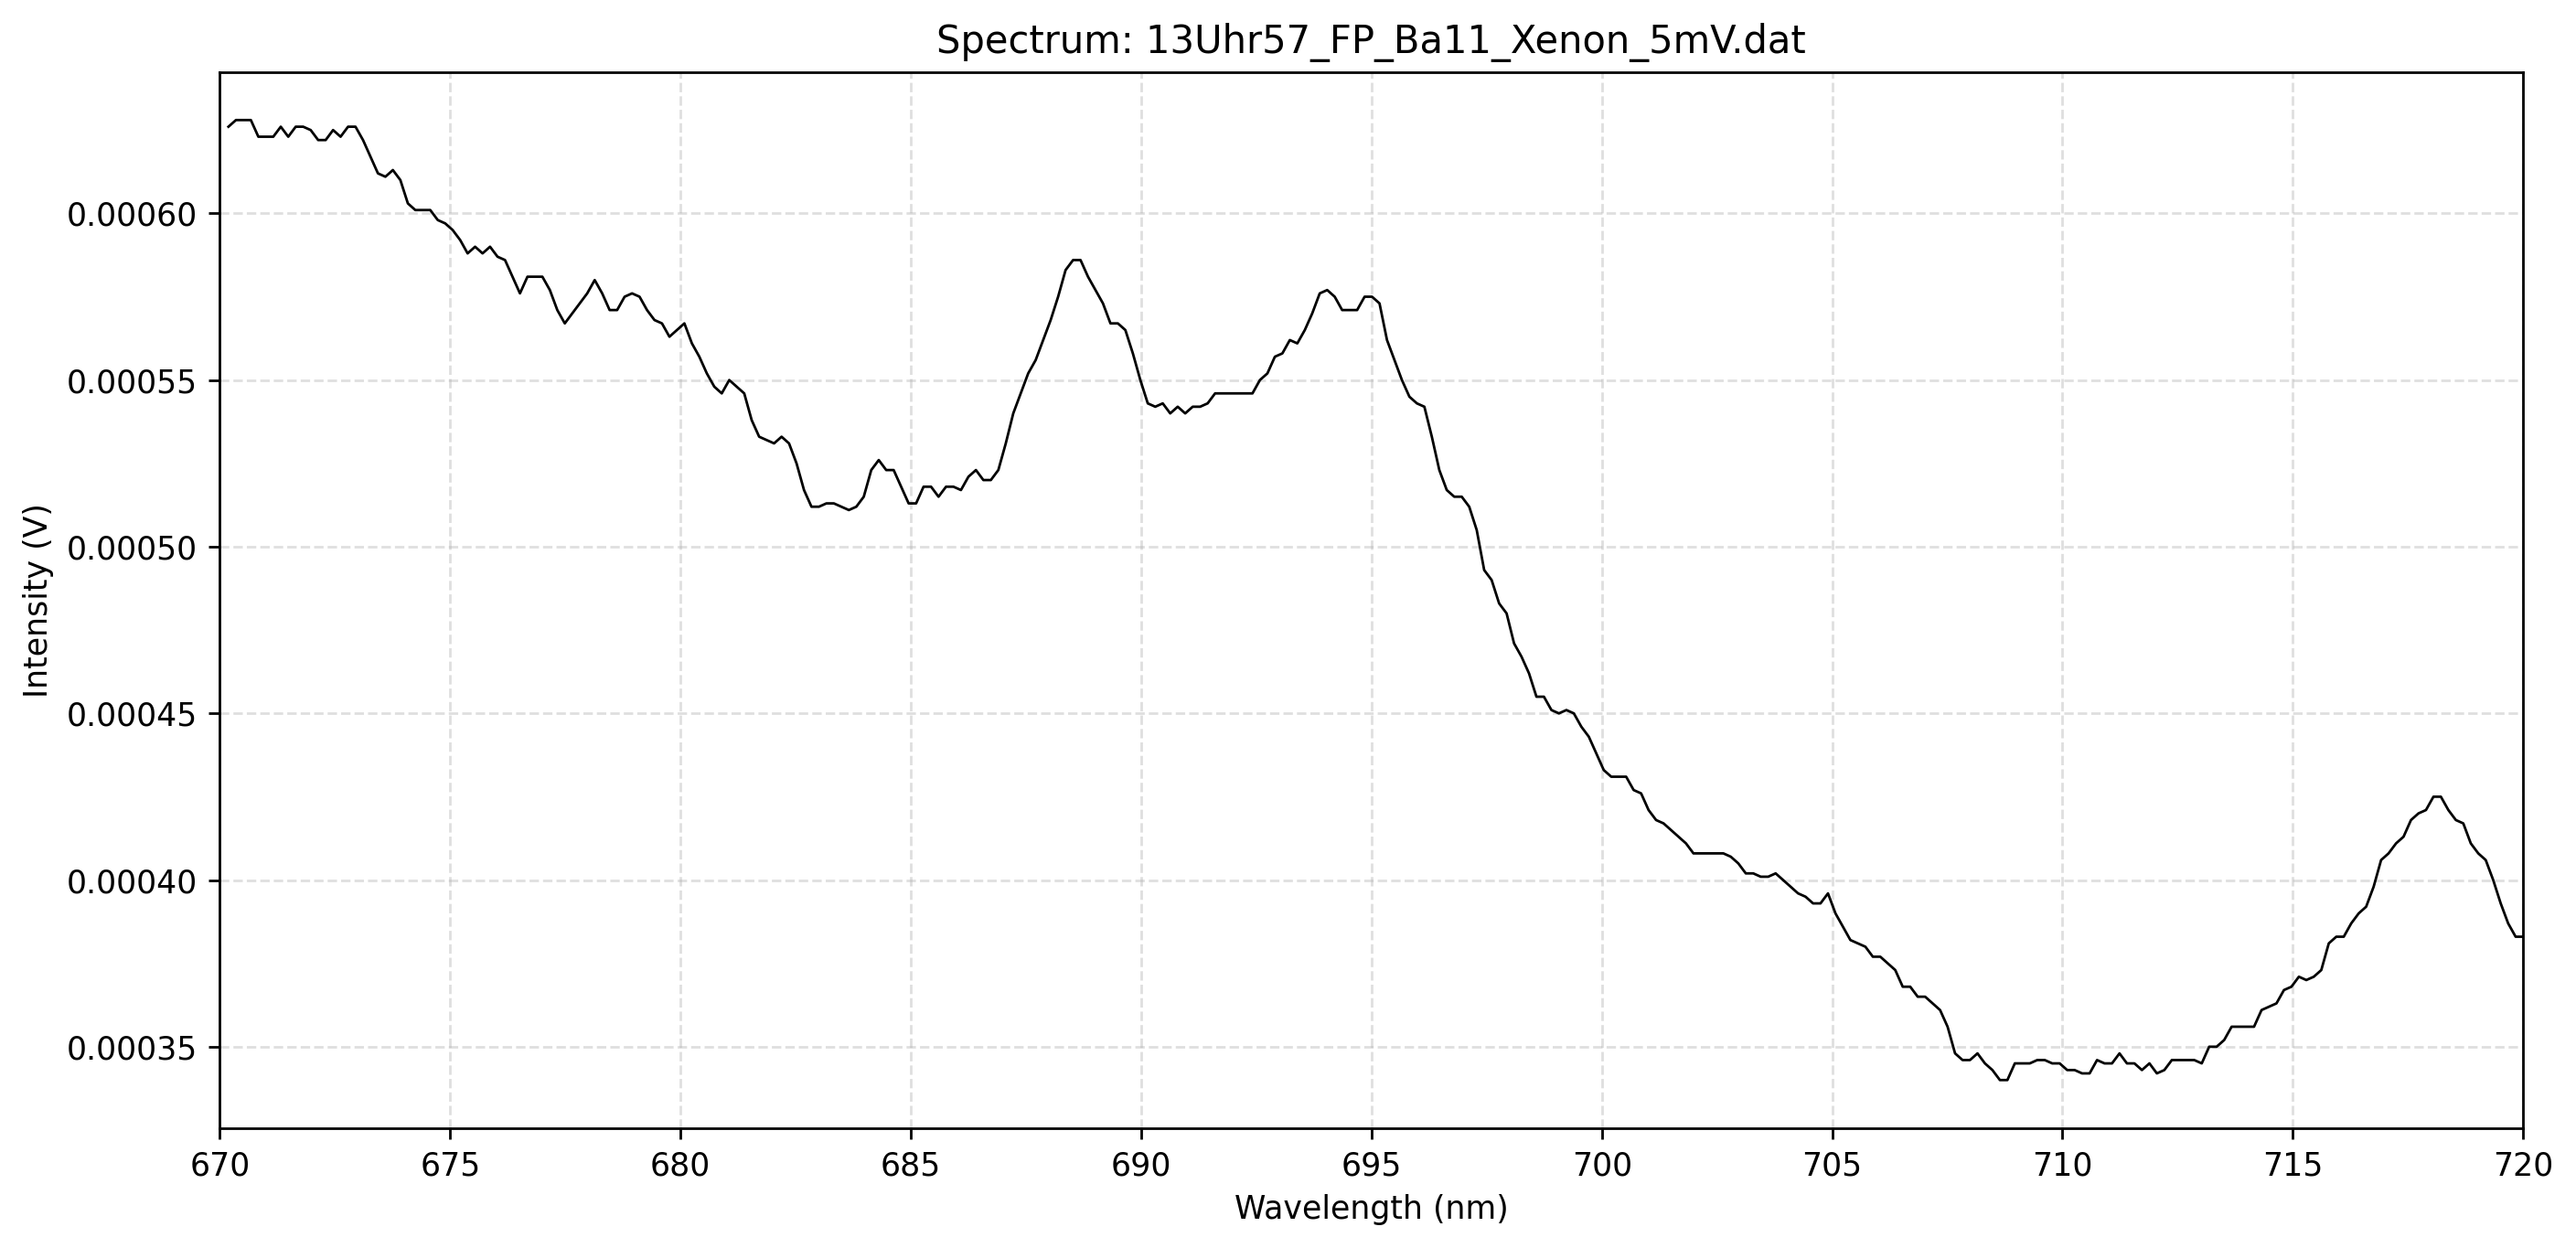

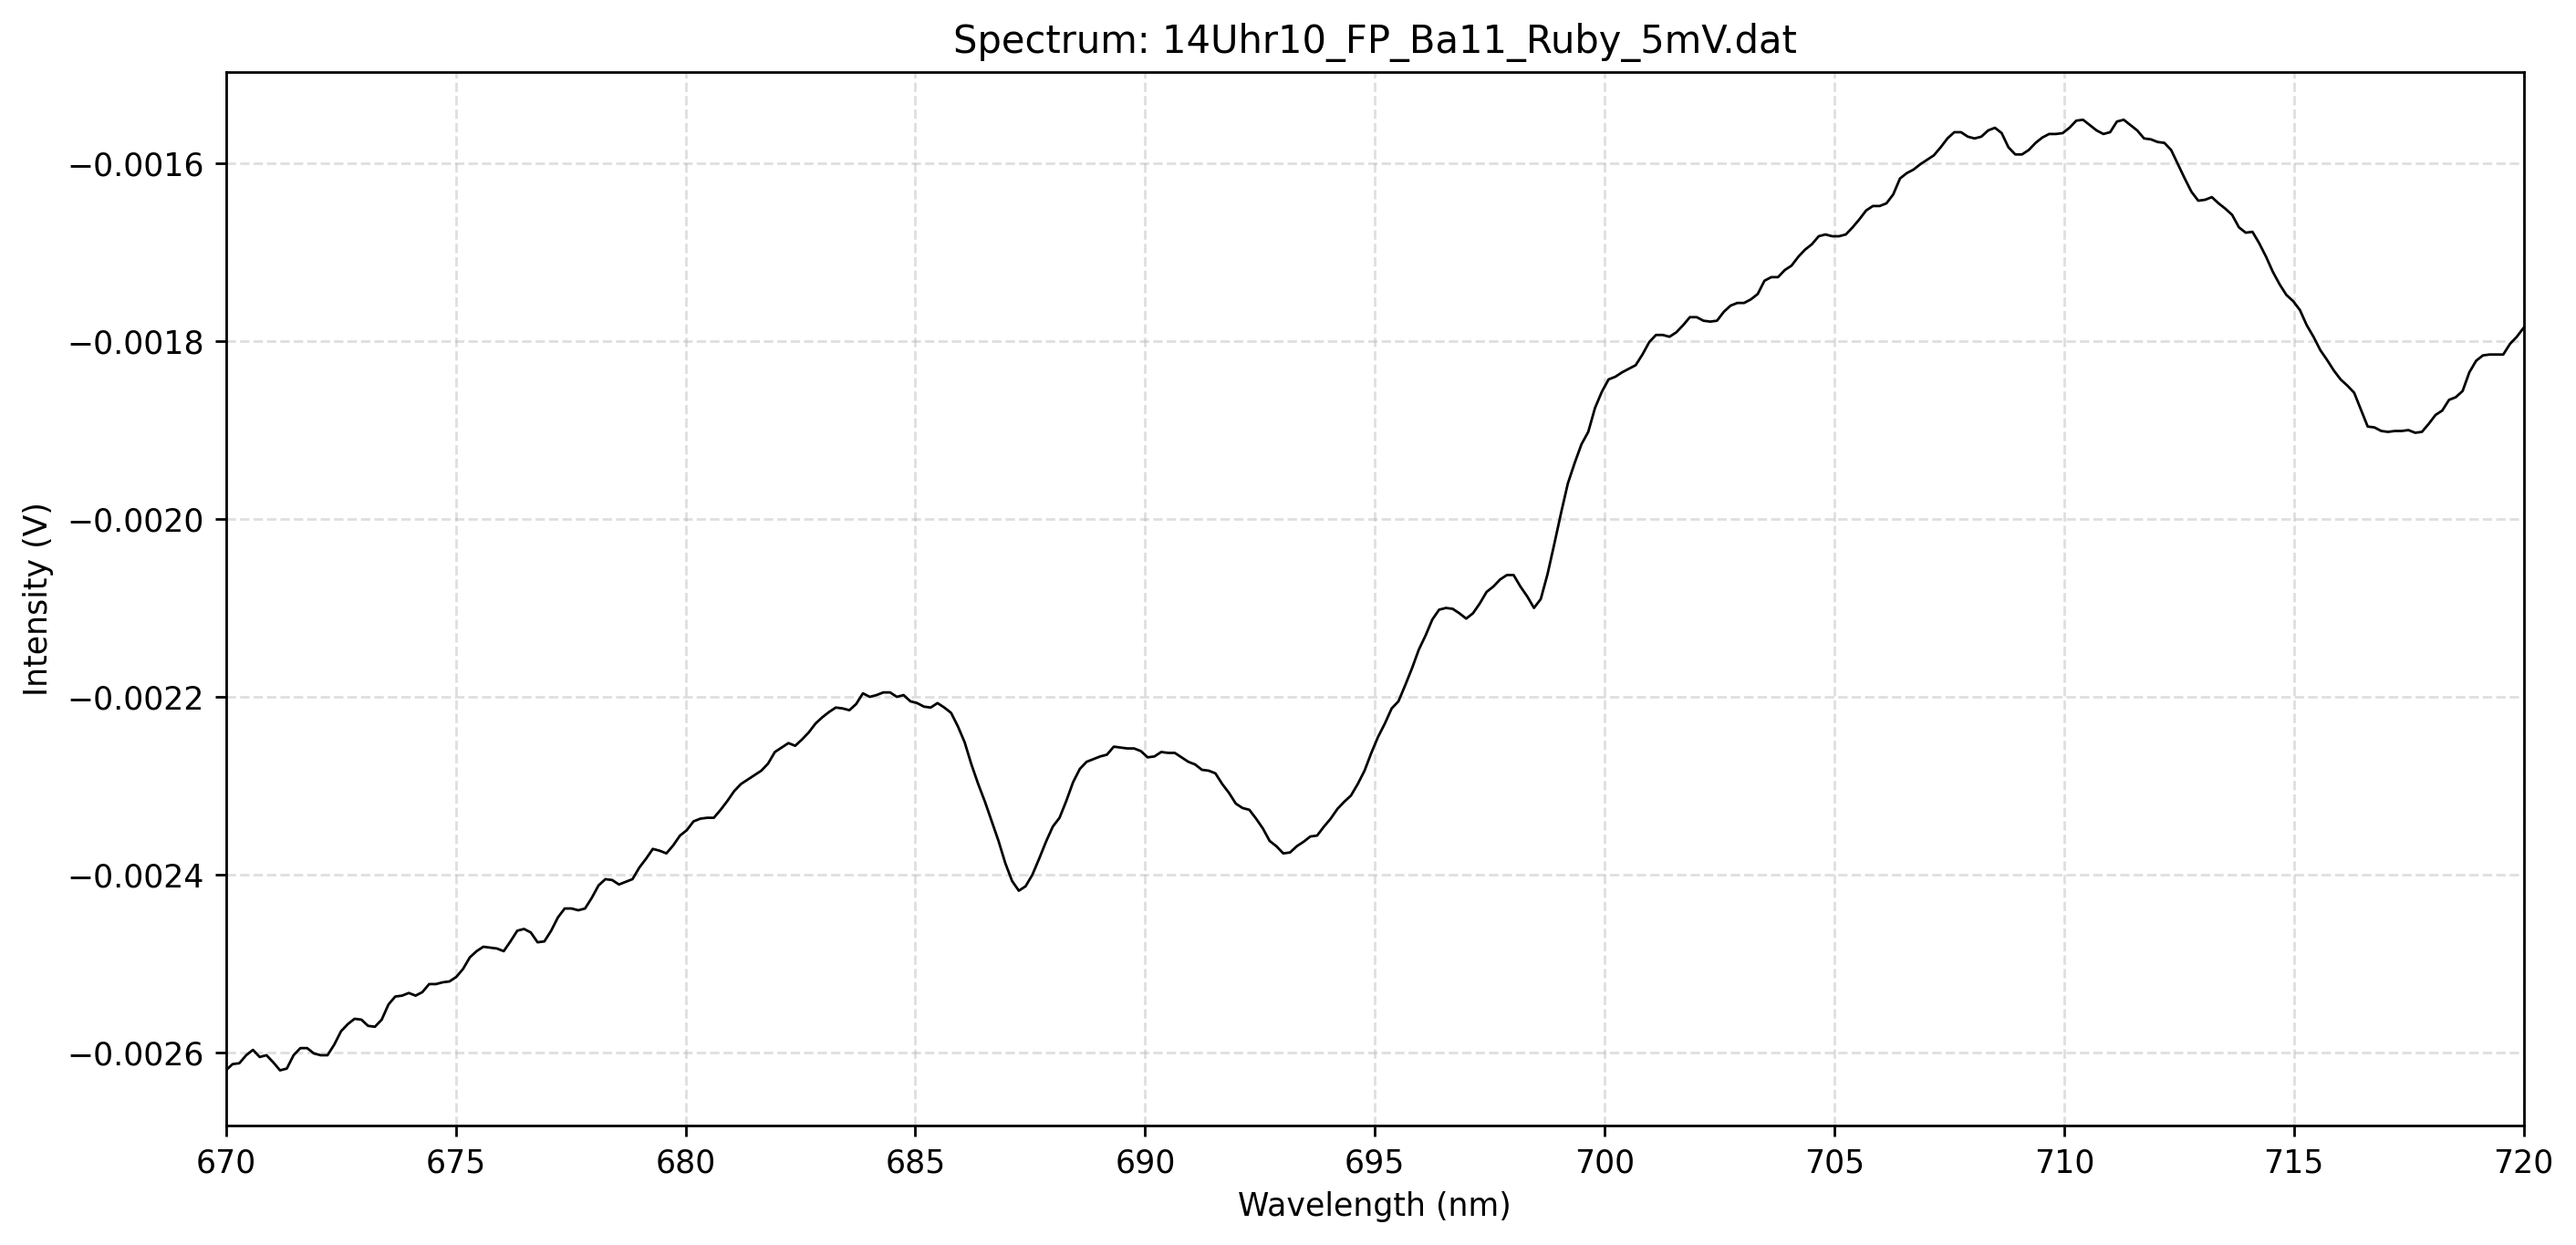

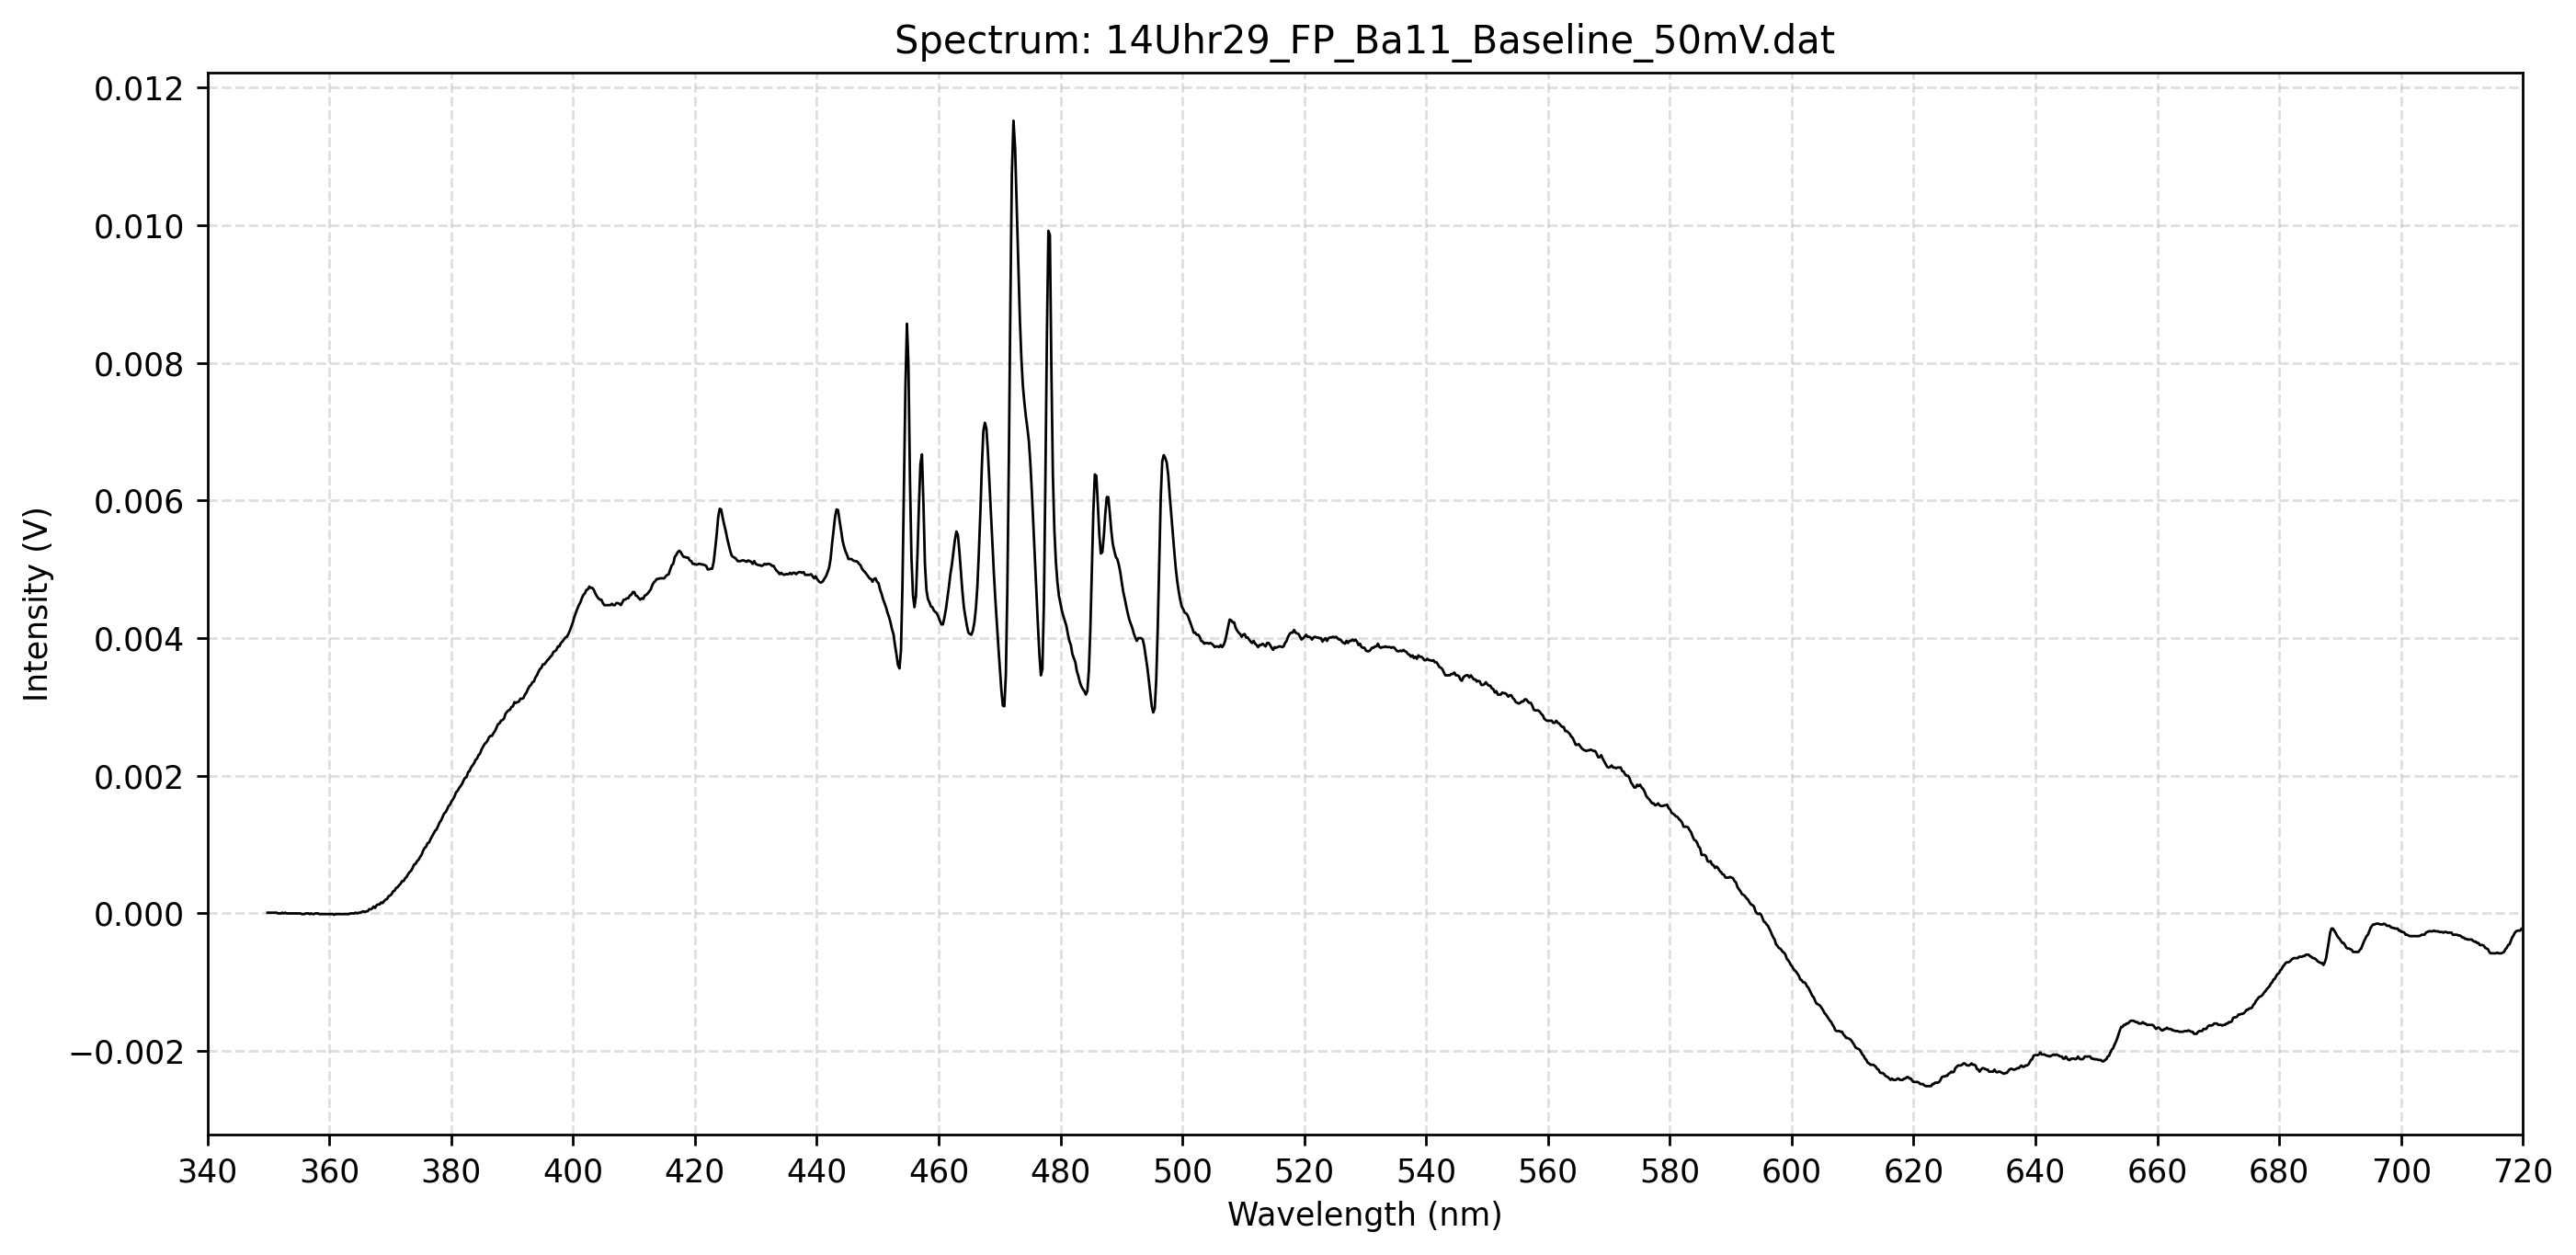

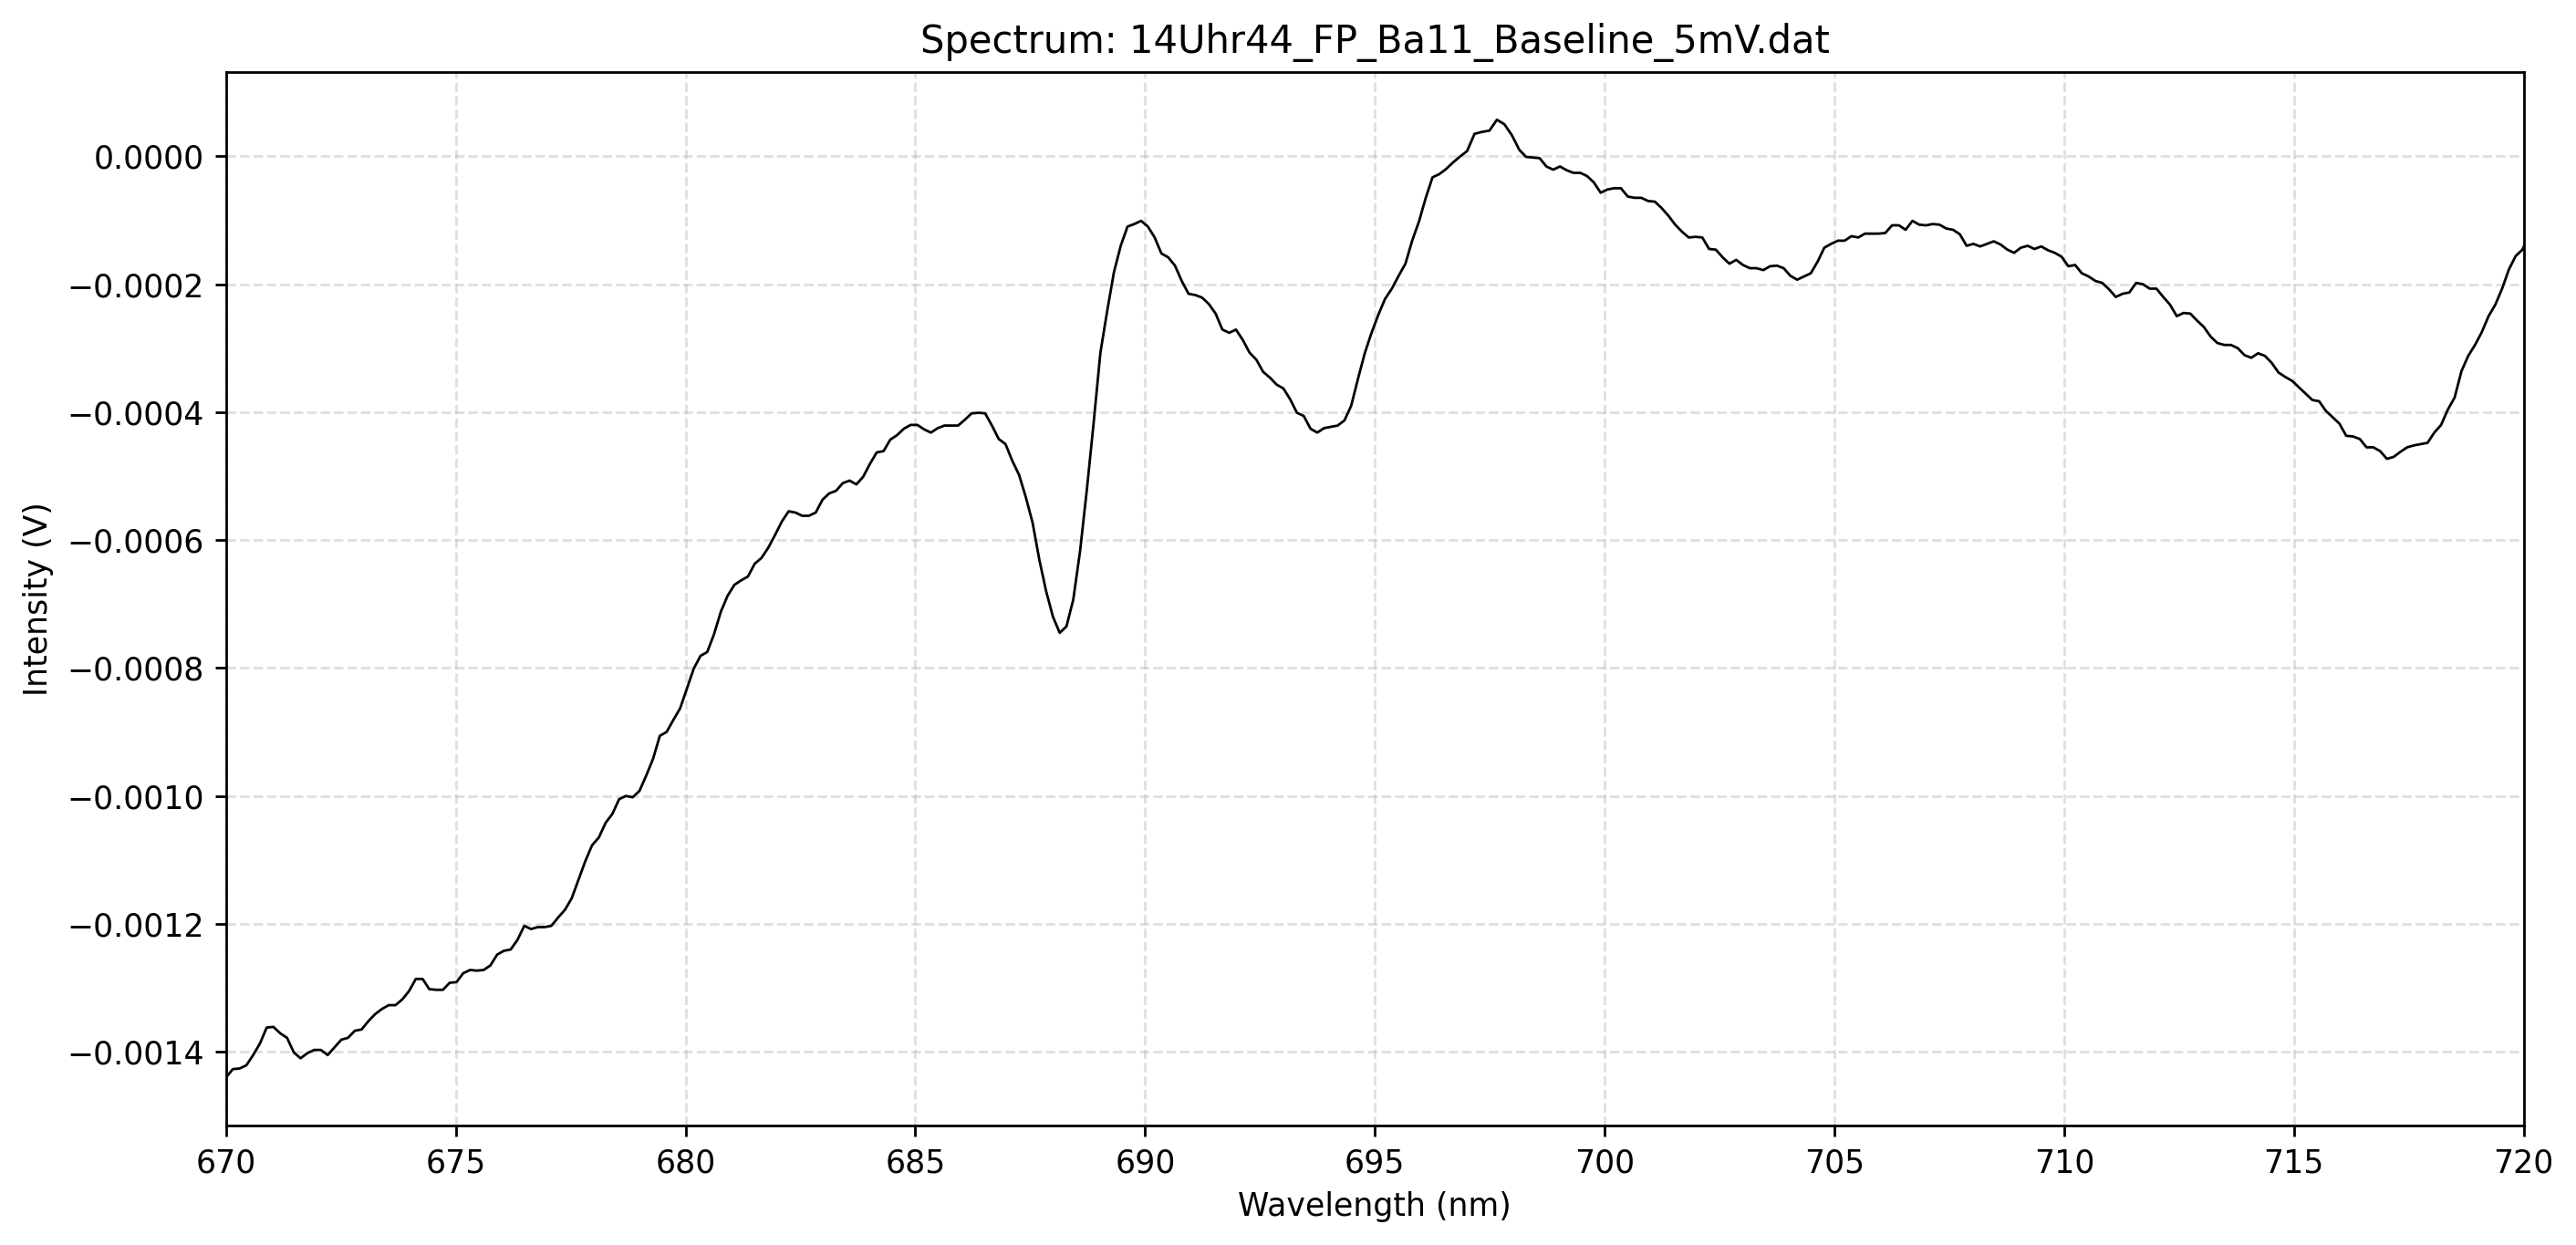

In [65]:
plot_spectrum("15Uhr03_FP_Ba11_Hg_Spectrum_50mV.dat")
plot_spectrum("13Uhr15_FP_Ba11_Difference_50mV.dat")
plot_spectrum("13Uhr26_FP_Ba11_Xenon_50mV.dat")
plot_spectrum("13Uhr36_FP_Ba11_Ruby_50mV.dat")
plot_spectrum("13Uhr51_FP_Ba11_Difference_5mV.dat")
plot_spectrum("13Uhr57_FP_Ba11_Xenon_5mV.dat")
plot_spectrum("14Uhr10_FP_Ba11_Ruby_5mV.dat")
plot_spectrum("14Uhr29_FP_Ba11_Baseline_50mV.dat")
plot_spectrum("14Uhr44_FP_Ba11_Baseline_5mV.dat")

### Mercury Calibration

This code loads our recorded Hg spectrum and determines the wavelength offset of the monochromator.

We manually specify six approximate peak positions (based on the plotted spectrum).  
For each guess, the code looks ±3 nm around it and simply takes the **maximum intensity** in that region.  
This gives the exact measured wavelength of each Hg emission line.

We then compare these measured peak positions to the literature values and compute the individual shifts  
Δλᵢ = λ_ref − λ_meas.  
Their mean gives the global wavelength correction, which we apply to all spectra using `apply_calibration()`.

In [15]:
import numpy as np

# --- Known Hg reference wavelengths (nm) ---
hg_ref = np.array([365.0, 404.7, 435.8, 546.1, 577.0, 579.0])

# --- Approximate peak positions seen by eye in the spectrum ---
initial_guesses = np.array([369, 409, 440, 551, 583, 585])

# --- The only file this calibration will use ---
hg_filename = "15Uhr03_FP_Ba11_Hg_Spectrum_50mV.dat"


def load_hg_spectrum():
    """Load the fixed mercury calibration file and return (wavelength, intensity)."""
    with open(hg_filename, "r", encoding="utf-8") as f:
        start = float(f.readline().replace(",", "."))
        gear  = float(f.readline().replace(",", "."))
        direction = float(f.readline().replace(",", "."))

        data = np.loadtxt((line.replace(",", ".") for line in f))

    t = data[:, 0]
    I_raw = data[:, 1]

    # Wavelength axis
    wl = start + direction * gear * t

    # Flip sign so peaks go upward
    I = -I_raw

    # Ensure ascending wavelength order
    if wl[0] > wl[-1]:
        wl = wl[::-1]
        I  = I[::-1]

    return wl, I


def refine_peak(wl, I, guess, window=3):
    """Refine peak position by taking the maximum within ±window nm of a guessed location."""
    mask = (wl >= guess - window) & (wl <= guess + window)
    wl_win = wl[mask]
    I_win  = I[mask]

    idx = np.argmax(I_win)
    return wl_win[idx]


def perform_hg_calibration():
    """
    Finds the exact measured Hg peak wavelengths and computes the wavelength offset Δλ.
    """
    wl, I = load_hg_spectrum()

    # refine all 6 peaks
    measured = np.array([refine_peak(wl, I, g) for g in initial_guesses])

    # compute shifts
    shifts = hg_ref - measured
    shift_mean = shifts.mean()

    print("Reference Hg lines (nm):", hg_ref)
    print("Measured Hg peaks (nm): ", measured)
    print("Individual shifts (nm):", shifts)
    print(f"\nMean wavelength shift Δλ = {shift_mean:.3f} nm")

    return shift_mean, measured, wl, I


# --- Run calibration immediately ---
shift, measured_peaks, wl_hg, I_hg = perform_hg_calibration()


def apply_calibration(wavelength, shift=shift):
    """Apply Δλ shift to any wavelength axis."""
    return np.asarray(wavelength) + shift


Reference Hg lines (nm): [365.  404.7 435.8 546.1 577.  579. ]
Measured Hg peaks (nm):  [369.3 409.  440.4 550.8 581.7 583.8]
Individual shifts (nm): [-4.3 -4.3 -4.6 -4.7 -4.7 -4.8]

Mean wavelength shift Δλ = -4.567 nm
